In [2]:
import pandas as pd
from pathlib import Path
from math import ceil # arredondar pra cima
#import numpy as np

In [3]:
BASE_DIR = Path("..").resolve()
INFO_PV_FILE = BASE_DIR/'data'/'InfoPV'/'power_station_metadata.csv'
SOLAR_STATION_FILES = BASE_DIR/'data'/'InfoPV'/'solar_station'
OUTPUT_DIR = BASE_DIR/'output'
PV_list = pd.read_csv(INFO_PV_FILE)


In [82]:
t_simulation = 24*60*1 #tempo total de simulação em minutos
npts_origin = ceil(t_simulation/15) #quantidade total de passos da simulação
step = '20min'

In [78]:
class PVShapeConverter:
    def __init__(
            self,  
            PV_kv, 
            PV_kva,
            PV_bus:str,
            PV_phases:int,
            PV_id:int, 
            PV_curve_id:int, 
            npts_origin:int, 
            PV_list:pd.DataFrame, 
            start:int=96
            ):
        
        """
        Recebe os dados do PV e relaciona aos arquivos do dataset.

        Parâmetros: 
        - PV_kv: Tensão de fase da barra de instalação do PV.
        - PV_kva: Potência instalada do PV.
        - PV_bus: Barra em que o PV será conectado.
        - PV_phases: Número de fases da barra que o PV será conectado.
        - PV_id: Número inteiro associado ao nome que será atribuído ao gerador.
        - PV_curve_id: Número inteiro associado ao arquivo com as curvas que será atribuído ao gerador, vai de 1 a 51.
        - npts_origin: Número de pontos que as curvas têm no arquivo original, com passo de simulação de 15 minutos.
        - PV_list: Dataframe que recebe os dados do arquivo de metadados.
        - start: Argumento que define a partir de que pontos os dados originais serão utilizados, ignorando os pontos anteriores ao definido.
        """

        #Definição os parâmetros para criação do PV

        #   Atribuição do PV no arquivo de metadados do BR-PVGen com base no número de id
        if pd.isna(PV_curve_id):
           self.curve_id = PV_id #Atribui o valor do id da curva igual ao id painel se não for fornecido
        else:
            self.curve_id = PV_curve_id
        #   Garante que o lavor do id da curva vai estar entre 1 e 51 (correspondente aos arquivos)
        if self.curve_id > 51:
            self.curve_id = PV_curve_id % 51 
        elif self.curve_id <= 0:
            print('\nWARNING: O número de id de entrada do PV foi {PV_curve_id}.')
            print('O número de id de entrada do  PV deve ser igual ou maior que 1, portanto foi atribuído a ele o valor default.')
            self.curve_id=1

        self.curve = PV_list.iloc[self.curve_id-1, 1]

        self.FILE_CSV = self.curve + '.csv'
        self.SOLAR_STATION_FILE = SOLAR_STATION_FILES/self.FILE_CSV
        self.solar_station_curves = pd.read_csv(self.SOLAR_STATION_FILE)

        #Nome
        self.name = 'PV-'+str(PV_id)

        #Qtd. de fases
        self.phases = PV_phases

        #Barra
        self.bus = PV_bus

        #Tensão de fase
        self.kv = PV_kv

        #Potência instalada
        if pd.isna(PV_kva): #Atribui o valor do dataset se não for declarada
            self.kva = (PV_list.iloc[self.curve_id-1, 3])*1000
        else:
            self.kva = PV_kva

        #Irradiância de base
        self.irrad = 0.8 * 1000

        #Pmpp
        self.pmpp = PV_kva

        #Temperatura de base
        self.temperature = 25

        #Fator de potência
        self.pf = 1

        #Curva de eficiência
        self.effcurve = 'New XYCurve.MyEff npts=4 xarray=[0.1, 0.2, 0.4, 1.0] yarray=[0.86, 0.90, 0.93, 0.97]'

        #Curva de potência máxima vs temperatura
        self.ptcurve = 'New XYCurve.MyPvsT npts=4 xarray=[0, 25, 75, 100] yarray=[1.2, 1.0, 0.8, 0.6]'

        #Curva de irradiância
        self.npts = npts_origin
        #   Pega os valores de irradiância incidente no plano dos paineis (poa = plane of array).
        self.irrad_curve = ((self.solar_station_curves['poa_irradiance_wm2'].iloc[start:self.npts+start])/self.irrad)
        for i in range(len(self.irrad_curve)):
            if pd.isna(self.irrad_curve.iloc[i]) or self.irrad_curve.iloc[i] < 0:
                self.irrad_curve.iloc[i] = 0
        
        #Curva de temperatura
        self.temperature_curve = (self.solar_station_curves['ambient_temperature_celsius'].iloc[start:self.npts+start])/self.temperature
        for i in range(len(self.temperature_curve)):
            if pd.isna(self.temperature_curve.iloc[i]) or self.temperature_curve.iloc[i] < 0:
                self.temperature_curve.iloc[i] = 0
        
        #Tensão mínima aplicada
        self.vminpu = 0.001

        #Modelo do objeto criado
        self.model = 1

        #Curva de tempo 
        self.datetime = self.solar_station_curves['datetime'].iloc[start:self.npts+start]
        self.datetime = pd.to_datetime(self.datetime)

        #Concatenação das curvas com a de tempo
        self.irrad_curve = pd.concat([self.datetime, self.irrad_curve], axis=1)
        self.temperature_curve = pd.concat([self.datetime, self.temperature_curve], axis=1)
        
        #Definição da coluna de tempo como índice
        self.irrad_curve.set_index('datetime', inplace=True)
        self.temperature_curve.set_index('datetime', inplace=True)

    def CurveLinearInterpolation(self, nova_taxa):
        """
        Reamostra uma curva de série temporal (Pandas Series) para qualquer intervalo.
        
        Parâmetros:
        - curva: A variável com os dados (Pandas Series com índice de tempo).
        - nova_taxa: String do Pandas para tempo. Ex: '5s' (5 segundos), '1h' (1 hora), '15min'.
        """
        # 1. resample(nova_taxa): Agrupa os dados no novo intervalo
        # 2. mean(): Se for subamostragem (1h), calcula a média dos pontos. 
        #            Se for sobreamostragem (5s), coloca o valor original no ponto exato e NaN (vazio) no resto.
        # 3. interpolate(method='time'): Se houver buracos (sobreamostragem), preenche ligando os pontos proporcionalmente ao tempo.
        print('ok',PV) ######### Tirar depois #######################
        self.irrad_curve = (self.irrad_curve.resample(nova_taxa).mean().interpolate(method='time'))
        self.temperature_curve = self.temperature_curve.resample(nova_taxa).mean().interpolate(method='time')
        
        #Concatenação das curvas com a de tempo
        self.irrad_curve = self.irrad_curve.reset_index()
        self.temperature_curve = self.temperature_curve.reset_index()

    def GenerateCSV(self):
        self.irrad_curve.to_csv((str(OUTPUT_DIR) + '/' + self.name + '_data_irrad.csv'), index=False)



In [83]:
PV_PV_list = [
    {'PV_phases': 3, 'PV_bus': 97, 'PV_kv': 2.4, 'PV_kva': None,'PV_curve_id':None,'npts_origin': npts_origin, 'PV_list': PV_list },
    {'PV_phases': 3, 'PV_bus': 98, 'PV_kv': 2.4, 'PV_kva': None,'PV_curve_id':None,'npts_origin': npts_origin, 'PV_list': PV_list },
    {'PV_phases': 3, 'PV_bus': 99, 'PV_kv': 2.4, 'PV_kva': None,'PV_curve_id':None,'npts_origin': npts_origin, 'PV_list': PV_list }
]

generator = []

for PV, PV_data in enumerate(PV_PV_list):
    generator.append(PVShapeConverter(
        PV_id = PV+1, 
        PV_phases = PV_data['PV_phases'], 
        PV_bus = PV_data['PV_bus'],
        PV_kv = PV_data['PV_kv'], 
        PV_kva = PV_data['PV_kva'], 
        PV_curve_id = PV_data['PV_curve_id'], 
        npts_origin = PV_data['npts_origin'], 
        PV_list = PV_data['PV_list'] 
    ))
    generator[PV].CurveLinearInterpolation(step)
    generator[PV].GenerateCSV()

for x in range(3):
    print(generator[x].kva)

ok 0
ok 1
ok 2
5000.0
1000.0
1000.0


In [84]:
generator[0].temperature_curve

,datetime,ambient_temperature_celsius
0,2024-03-27 00:00:00+00:00,0.802182
1,2024-03-27 00:20:00+00:00,0.780000
2,2024-03-27 00:40:00+00:00,0.780000
3,2024-03-27 01:00:00+00:00,0.773652
4,2024-03-27 01:20:00+00:00,0.772000
...,...,...
67,2024-03-27 22:20:00+00:00,0.771817
68,2024-03-27 22:40:00+00:00,0.760000
69,2024-03-27 23:00:00+00:00,0.763674
70,2024-03-27 23:20:00+00:00,0.772000


In [85]:
generator[0].irrad_curve

,datetime,poa_irradiance_wm2
0,2024-03-27 00:00:00+00:00,0.0
1,2024-03-27 00:20:00+00:00,0.0
2,2024-03-27 00:40:00+00:00,0.0
3,2024-03-27 01:00:00+00:00,0.0
4,2024-03-27 01:20:00+00:00,0.0
...,...,...
67,2024-03-27 22:20:00+00:00,0.0
68,2024-03-27 22:40:00+00:00,0.0
69,2024-03-27 23:00:00+00:00,0.0
70,2024-03-27 23:20:00+00:00,0.0


In [314]:
generator[2].temperature_curve

,ambient_temperature_celsius
datetime,
2024-03-27 00:00:00+00:00,0.777662
2024-03-27 00:10:00+00:00,0.780318
2024-03-27 00:20:00+00:00,0.781182
2024-03-27 00:30:00+00:00,0.782047
2024-03-27 00:40:00+00:00,0.779809
...,...
2024-03-27 23:00:00+00:00,0.818260
2024-03-27 23:10:00+00:00,0.814322
2024-03-27 23:20:00+00:00,0.816651


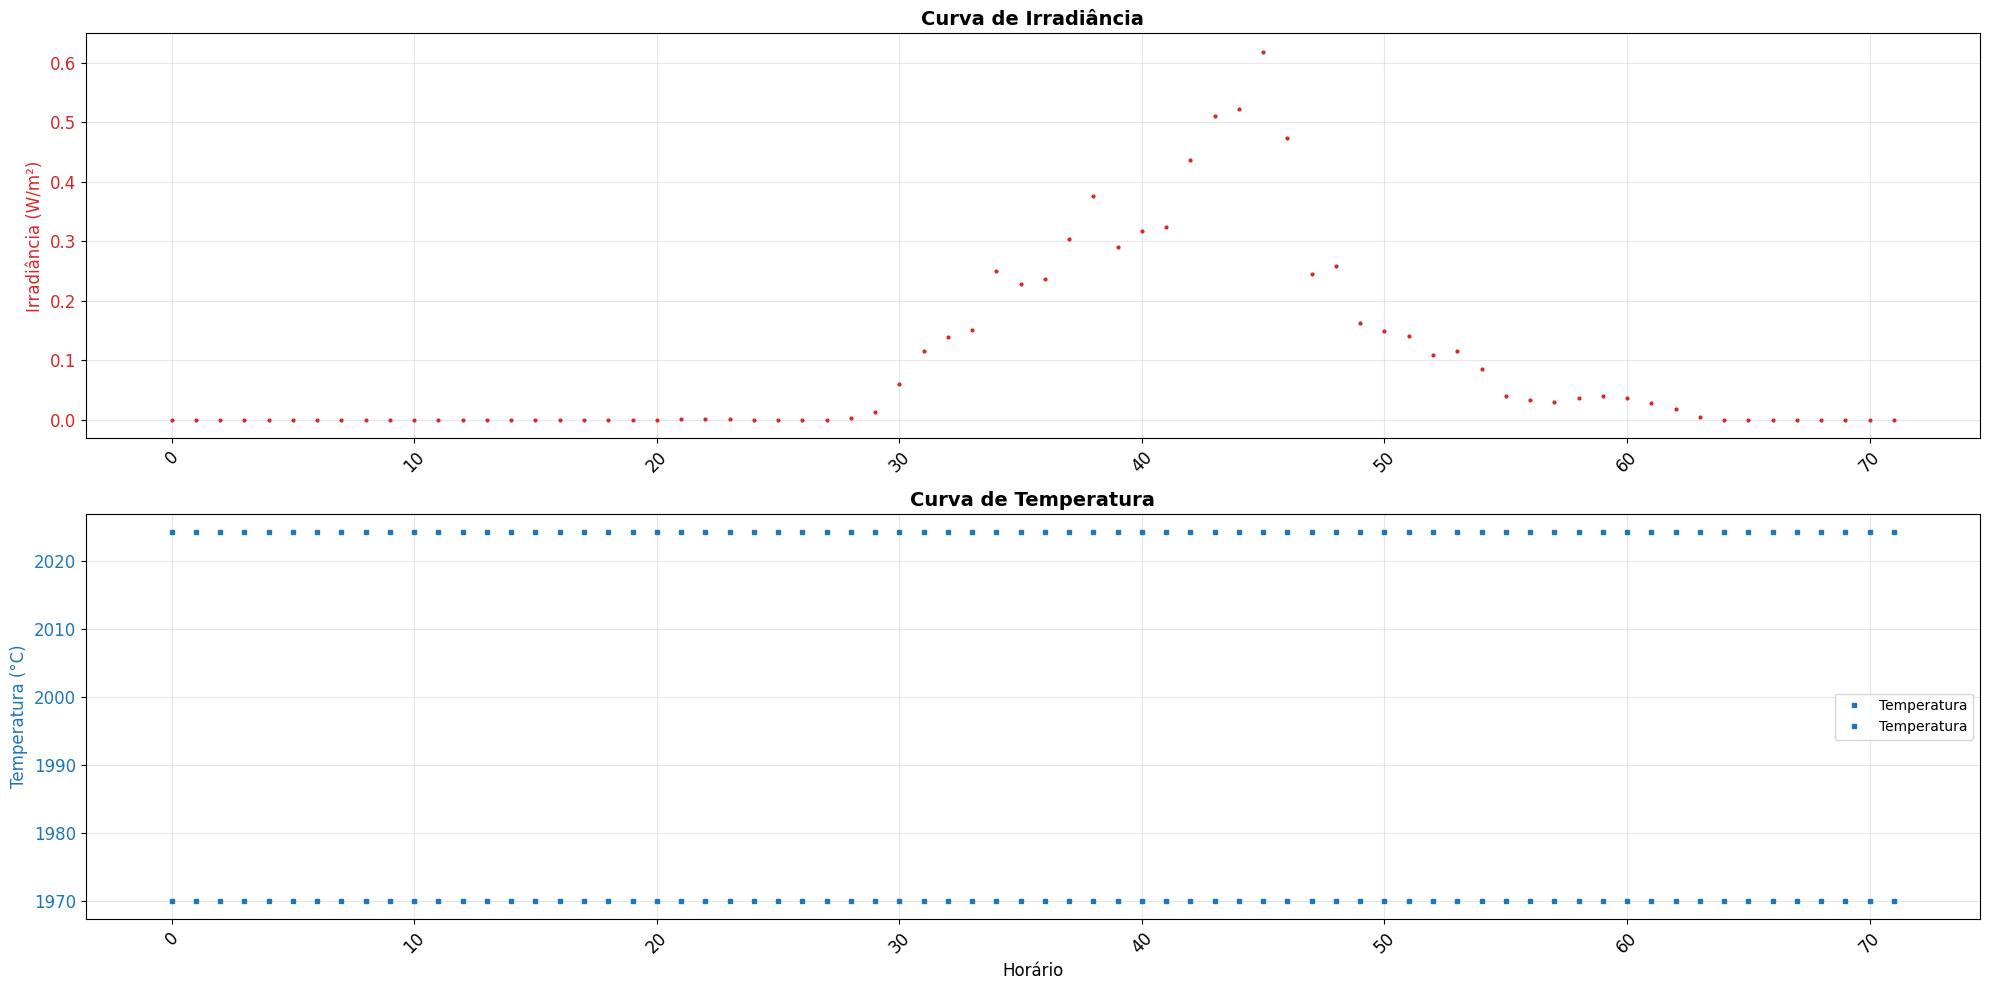

In [88]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Criar figura com 2 subplots (2 linhas, 1 coluna)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

# ===== SUBPLOT 1: Irradiância =====
# Adiciona 'o' como marcador (ponto) e remove a linha com linestyle=''
ax1.plot(generator[0].irrad_curve['poa_irradiance_wm2'], 
         color='tab:red', 
         marker='o',      # Adiciona ponto em cada dado
         linestyle='',    # Remove a linha (opcional)
         markersize=2)    # Tamanho do ponto (ajuste conforme necessário)

# Configurações do eixo X para o primeiro subplot
#ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # A cada 1 hora
#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Aumentar o tamanho da fonte dos ticks
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelcolor='tab:red', labelsize=12)

# Adicionar título e label do eixo Y para o primeiro subplot
ax1.set_ylabel('Irradiância (W/m²)', fontsize=12, color='tab:red')
ax1.set_title('Curva de Irradiância', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)  # Adiciona grade leve

# ===== SUBPLOT 2: Temperatura =====
# Plotar dados de temperatura (assumindo que existe conversor.temp_curve)
ax2.plot(generator[0].temperature_curve, 
         color='tab:blue', 
         marker='s',      # Marcador quadrado para diferenciar
         linestyle='',   
         linewidth=1.5,
         markersize=3,
         label='Temperatura')

# Configurações do eixo X para o segundo subplot
#ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))  # A cada 1 hora
#ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Aumentar o tamanho da fonte dos ticks
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelcolor='tab:blue', labelsize=12)

# Adicionar título e labels
ax2.set_xlabel('Horário', fontsize=12)
ax2.set_ylabel('Temperatura (°C)', fontsize=12, color='tab:blue')
ax2.set_title('Curva de Temperatura', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)  # Adiciona grade leve
ax2.legend(loc='best')  # Adiciona legenda

# Ajustar layout para não sobrepor elementos
plt.tight_layout()
plt.show()

In [316]:
# Pega todos os valores da segunda coluna e divide por 1000
valores = (irrad[irrad.columns[1]].values) / 1000

# Formata cada valor com 10 casas decimais, substituindo NaN por 0
valores_formatados = [
    "0.0" if pd.isna(v) or v == 0.0 else f"{v:.16f}"
    for v in valores
]

# Quantidade total de pontos
npts = len(valores_formatados)

# Cria a string no formato DSS
conteudo_dss = f"New LoadShape.MyShapePV1 npts={npts} minterval=1 mult=({', '.join(valores_formatados)})\n"

# Salva como arquivo .dss
nome_arquivo = "src/data/13Bus/LoadShapePV_2.dss"
with open(nome_arquivo, "w") as f:
    f.write(conteudo_dss)

print(f"Processamento concluído! {npts} pontos foram escritos no arquivo.")

NameError: name 'irrad' is not defined